# Extension - NLP interface: Low-level NLP formulation and solving

This is completely independent from all robotics code. Provides a generic interface to NLP formulation and calling various solvers.

In [1]:
import optsam as op
import numpy as np
import matplotlib.pylab as plt

Define simple SumOfSqr over 3 dimensions

In [2]:
class SimpleSumOfSqr:
    def __init__(self):
        self.dimension = 3
        self.types = [op.sos] * 3
        self.bounds = np.array([[-2,-2,-2],[2,2,2]])
        
    def evaluate(self, x):
        phi = x.copy()
        phi[0] = phi[0] - 1.
        J = np.eye(phi.size)
        return phi, J
    
    def getInitializationSample(self):
        return np.random.uniform(self.bounds[0], self.bounds[1])

nlp = SimpleSumOfSqr()

Define a solver

In [3]:
solver = op.NLP_Solver()
solver.setPyProblem(nlp)
solver.setSolver(op.OptMethod.Newton)

In [4]:
solver.solve(True)

--newton-- initial point f(x):1.85887 alpha:1 beta:1
--newton done-- final f(x):3.57959e-05


In [5]:
solver.getTrace_best()

array([[1.85887188e+00],
       [1.26120005e+00],
       [7.79086464e-01],
       [4.12531128e-01],
       [1.61534041e-01],
       [2.60952011e-02],
       [2.89946679e-03],
       [3.22162977e-04],
       [3.57958863e-05]])

In [6]:
import robotic as ry
import optsam as op
import numpy as np
import matplotlib.pylab as plt

In [7]:
class MyNLP:
    def __init__(self):
        self.dimension = 2
        self.types = [op.OT.sos] * 2
        self.bounds = np.array([[-2,-1], [2,3]])
        
        self.b = 3

    def evaluate(self, x):
        phi = np.array([ x[0]-1,
                         self.b*(x[1]-x[0]**2) ])
        J = np.array([[ 1, 0 ],
                      [ -2*self.b*x[0], self.b ]])
        return phi, J
    
nlp = MyNLP()

In [8]:
solver = ry.NLP_Solver()
solver.setPyProblem(nlp)
solver.setOptions(stepMax=.5, damping=1e-4)
solver.setTracing(trace_x=True, trace_errs=True)
nlp = solver.getProblem()

{ time: 0.000422, evals: 12, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 1.41056e-12, f: 0, x-dim: [2] }-- WARNING:py-Optim.cpp:getInitializationSample:65(-1) no getInitializationSample implemented -- using default fallback

{ time: 0.000343, evals: 22, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 1.09625e-14, x-dim: [2] }
{ time: 4.1e-05, evals: 24, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 4.07958e-06, x-dim: [2] }
{ time: 5.7e-05, evals: 27, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 3.30286e-11, x-dim: [2] }
{ time: 8.1e-05, evals: 33, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 1.74085e-10, x-dim: [2] }
{ time: 7.8e-05, evals: 39, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 2.28414e-13, x-dim: [2] }
{ time: 7.9e-05, evals: 45, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 2.1786e-13, x-dim: [2] }
{ time: 9.8e-05, evals: 53, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 5.60717e-14, x-dim: [2] }
{ time: 7.1e-05, evals: 58, done: 1, feasible: 1, eq: 0

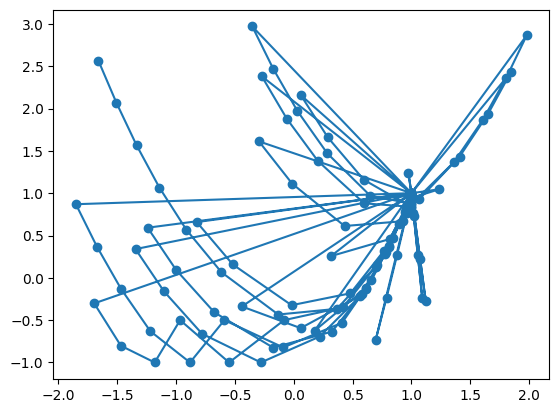

In [9]:
for i in range(20):
    ret = solver.solve(1)
    print(ret)
x = solver.getTrace_x()
E = solver.getTrace_errs()
z = solver.getTrace_best()
plt.plot(x[:,0], x[:,1], 'o-')

In [10]:
X = np.arange(-2, 2, 0.15)
Y = np.arange(-1, 3, 0.15)
X, Y = np.meshgrid(X, Y)
xy = np.hstack((X.reshape(-1,1),Y.reshape(-1,1)))
print(X.shape)
Z = np.array([nlp.eval_scalar(x)[0] for x in xy]).reshape(X.shape)

(27, 27)


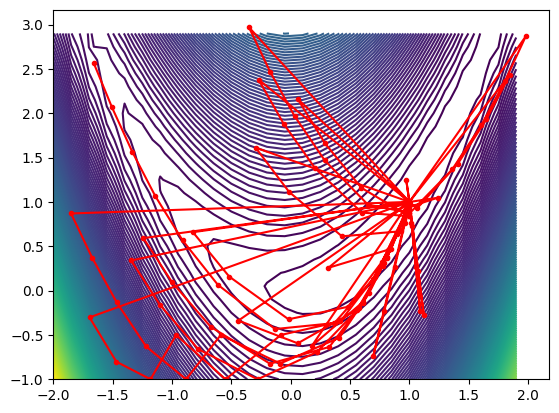

In [11]:
fig, ax = plt.subplots()
ax.contour(X,Y,Z, 200)
ax.plot(x[:,0], x[:,1], 'o-r', ms=3)

In [12]:
for i in range(20):
    x = solver.getProblem().getInitializationSample()
    r = solver.getProblem().checkJacobian(x, 1e-6)
    print(r, x)

True [1.96321714 2.48255659]
True [0.69061043 1.35082355]
True [-0.9799425   1.37218178]
True [-0.91311985  0.08192466]
True [-1.61627909  1.53022519]
True [-1.39490884  2.79544991]
True [-1.82958298  1.94035628]
True [-0.13801187 -0.10984184]
True [0.2859369  1.41827765]
True [0.79200713 1.65874263]
True [-1.30539116  2.0059782 ]
True [1.29966758 2.01238363]
True [-0.72380283  1.13020492]
True [-1.40978349  2.17051252]
True [1.65012398 2.17752457]
True [-1.9623664   1.04021141]
True [-0.81762537  1.23967576]
True [0.01669006 0.24006492]
True [1.9303154  2.85782124]
True [-0.20574558  0.21405543]
-- WARNING:py-Optim.cpp:getInitializationSample:65(-1) no getInitializationSample implemented -- using default fallback
checkJacobian -- SUCCESS (max diff error=3.48181e-08)
-- WARNING:py-Optim.cpp:getInitializationSample:65(-1) no getInitializationSample implemented -- using default fallback
checkJacobian -- SUCCESS (max diff error=5.98194e-08)
-- WARNING:py-Optim.cpp:getInitializationSample: